<a href="https://colab.research.google.com/github/Aditi-Creates/Earthquake-damage-detection/blob/main/earthquake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os

# Check what's inside your Google Drive
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Call for members- Literature Community .gform', 'Untitled form (File responses)', 'Untitled form.gform', 'Earthquake_project']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Earthquake_project'))

['Damage', 'undamaged', 'earthquake_model.h5', 'accuracy_graph.png', 'test_predictions.png', 'final_damage_levels.csv']


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import random

CLASSES = ['Damaged', 'No_Damage']
SPLITS  = {'train': 0.70, 'val': 0.15, 'test': 0.15}

# Create split folders
for cls in CLASSES:
    for split in SPLITS:
        os.makedirs(f'/content/split/{split}/{cls}', exist_ok=True)

# Split images
for cls in CLASSES:
    images = os.listdir(f'/content/dataset/{cls}')
    images = [f for f in images if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)

    total     = len(images)
    train_end = int(total * 0.70)
    val_end   = int(total * 0.85)

    sets = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:]
    }

    for split, imgs in sets.items():
        for img in imgs:
            shutil.copy(
                f'/content/dataset/{cls}/{img}',
                f'/content/split/{split}/{cls}/{img}'
            )

    print(f'{cls}: {train_end} train | {total-train_end-int(total*0.15)} val | {int(total*0.15)} test')

In [ ]:
from PIL import Image
import os

def preprocess_check(split_dir):
    corrupted = 0
    total = 0
    for cls in ['Damaged', 'No_Damage']:
        folder = f'{split_dir}/{cls}'
        for img_file in os.listdir(folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
                try:
                    img = Image.open(f'{folder}/{img_file}')
                    img.verify()  # check if image is corrupted
                except Exception as e:
                    print(f'Corrupted: {img_file} — removing')
                    os.remove(f'{folder}/{img_file}')
                    corrupted += 1
    print(f'Checked {total} images | Removed {corrupted} corrupted')

print("Checking train...")
preprocess_check('/content/split/train')
print("Checking val...")
preprocess_check('/content/split/val')
print("Checking test...")
preprocess_check('/content/split/test')

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build model
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x      = GlobalAveragePooling2D()(base.output)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

# Handle class imbalance (804 vs 300)
class_weight = {0: 1.0, 1: 2.5}

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight
)

# Save model to Drive
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved to Google Drive!")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build model
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x      = GlobalAveragePooling2D()(base.output)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

# Handle class imbalance (804 vs 300)
class_weight = {0: 1.0, 1: 2.5}

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight
)

# Save model to Drive
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved to Google Drive!")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build MobileNetV2
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Class weights to handle imbalance
class_weight = {0: 1.0, 1: 2.68}  # 804/300 ratio

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr]
)

# Save
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved!")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.2%}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Earthquake_project/accuracy_graph.png')
plt.show()
print("✅ Graph saved to Drive!")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Pick first test image
test_folder = '/content/split/test/Damaged'
test_img = os.listdir(test_folder)[0]

img = image.load_img(f'{test_folder}/{test_img}', target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]
label = 'Damaged' if pred > 0.5 else 'No_Damage'
confidence = pred if pred > 0.5 else 1 - pred

plt.imshow(image.load_img(f'{test_folder}/{test_img}'))
plt.title(f'Prediction: {label} ({confidence*100:.1f}%)')
plt.axis('off')
plt.show()

print(f"Prediction : {label}")
print(f"Confidence : {confidence*100:.1f}%")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import random
import os

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)[0][0]
    label = 'Damaged' if pred > 0.5 else 'No_Damage'
    confidence = pred if pred > 0.5 else 1 - pred
    return label, confidence * 100

# Pick 6 random images from test folder (mix of both classes)
test_images = []
for cls in ['Damaged', 'No_Damage']:
    folder = f'/content/split/test/{cls}'
    imgs = os.listdir(folder)
    random.shuffle(imgs)
    for img in imgs[:3]:  # 3 from each class
        test_images.append((f'{folder}/{img}', cls))

# Plot results
plt.figure(figsize=(15, 10))
for i, (img_path, true_label) in enumerate(test_images):
    label, confidence = predict_image(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(image.load_img(img_path))

    # Green title if correct, red if wrong
    color = 'green' if label == true_label else 'red'
    plt.title(f'Pred: {label}\nConf: {confidence:.1f}%\nTrue: {true_label}',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Earthquake_project/test_predictions.png')
plt.show()
print("✅ Saved to Drive!")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/Earthquake_project/earthquake_model.h5'
)

print("✅ Model Loaded Successfully")

In [ ]:
model.summary()

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

In [ ]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

print("✅ Feature Extractor Created")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

feature_gen = ImageDataGenerator(rescale=1./255)

damaged_data = feature_gen.flow_from_directory(
    '/content/split/test',
    classes=['Damaged'],
    target_size=(224,224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

features = feature_extractor.predict(damaged_data)

print(features.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

print("✅ Features Standardized")
print(features_scaled.shape)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

clusters = dbscan.fit_predict(features_scaled)

print("Cluster Labels:")
print(clusters)

In [ ]:
import numpy as np

unique_clusters = np.unique(clusters)

print("Unique Clusters:", unique_clusters)

for cluster in unique_clusters:
    count = np.sum(clusters == cluster)
    print(f"Cluster {cluster}: {count} images")

In [ ]:
print(features_scaled.shape)

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

for eps in [5, 8, 10, 12, 15, 20]:
    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(features_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        f"eps={eps} | clusters={n_clusters} | noise={n_noise}"
    )

In [ ]:
import pandas as pd

cluster_counts = pd.Series(clusters).value_counts().sort_index()

print(cluster_counts)

In [ ]:
results = pd.DataFrame({
    'Image': damaged_data.filenames,
    'Cluster': clusters
})

results.head()

In [ ]:
import pandas as pd

print(results['Cluster'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import random

for cluster_id in sorted(results['Cluster'].unique()):

    cluster_imgs = results[
        results['Cluster'] == cluster_id
    ]['Image'].tolist()

    sample_imgs = random.sample(
        cluster_imgs,
        min(5, len(cluster_imgs))
    )

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(sample_imgs):

        img_path = f"/content/split/test/{img_name}"

        plt.subplot(1,5,i+1)
        plt.imshow(image.load_img(img_path))
        plt.axis('off')

    plt.suptitle(f'Cluster {cluster_id}')
    plt.show()

In [ ]:
cluster_mapping = {
    0: 'Low Damage',
    1: 'Moderate Damage',
    2: 'High Damage',
    3: 'Severe Damage'
}

In [ ]:
results['Damage_Level'] = results['Cluster'].map(cluster_mapping)

results.head()

In [ ]:
results.to_csv(
    '/content/drive/MyDrive/Earthquake_project/final_damage_levels.csv',
    index=False
)

print("✅ Final damage levels saved")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_damage_level(img_path):

    # Load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Stage 1: Damage Detection
    pred = model.predict(img_array, verbose=0)[0][0]

    if pred <= 0.5:
        return "No Damage"

    # Stage 2: Feature Extraction
    feature = feature_extractor.predict(img_array, verbose=0)

    feature_scaled = scaler.transform(feature)

    cluster = kmeans.predict(feature_scaled)[0]

    return cluster_mapping[cluster]

In [ ]:
import os

folder = "/content/split/test/Damaged"

print(os.listdir(folder)[:10])

In [ ]:
result = predict_damage_level(
    "/content/split/test/Damaged/9b742d9a15edea37a823ac21ac6987a0.jpg"
)

print("Damage Level:", result)

In [ ]:
img = image.load_img(
    "/content/split/test/Damaged/0010db654b64dfa30d3a3941228bace8.jpg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array, verbose=0)[0][0]

print("Prediction Score:", pred)

In [ ]:
print(train_data.class_indices)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print(train_data.class_indices)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_damage_level(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    print("Raw Prediction:", pred)

    # Damaged = 0
    # No_Damage = 1

    if pred > 0.5:
        return "No Damage"

    feature = feature_extractor.predict(img_array, verbose=0)

    feature_scaled = scaler.transform(feature)

    cluster = kmeans.predict(feature_scaled)[0]

    return cluster_mapping[cluster]

In [ ]:
result = predict_damage_level(
    "/content/split/test/Damaged/21dc54adc171dbd7c7b25568c0d153de.jpg"
)

print("Final Result:", result)

In [ ]:
print(cluster_mapping)

In [ ]:
import os

print(os.path.exists(
    "/content/split/test/Damaged/21dc54adc171dbd7c7b25568c0d153de.jpg"
))

In [ ]:
import os

files = os.listdir("/content/split/test/Damaged")

print("Number of files:", len(files))
print(files[:20])

In [ ]:
target = "21dc54adc171dbd7c7b25568c0d153de"

for f in os.listdir("/content/split/test/Damaged"):
    if target in f:
        print(f)

In [ ]:
import os

folder = "/content/split/test/Damaged"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print(img_path)

result = predict_damage_level(img_path)

print(result)

In [ ]:
print(os.listdir("/content/split/test"))

In [ ]:
import os

folder = "/content/split/test/Damaged"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Testing:", img_name)

result = predict_damage_level(img_path)

print("Final Result:", result)

In [ ]:
folder = "/content/split/test/No_Damage"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Testing:", img_name)

result = predict_damage_level(img_path)

print("Final Result:", result)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import shutil

DAMAGE_DIR   = '/content/drive/MyDrive/Earthquake_project/Damage/Images'
NODAMAGE_DIR = '/content/drive/MyDrive/Earthquake_project/undamaged'

os.makedirs('/content/dataset/Damaged', exist_ok=True)
os.makedirs('/content/dataset/No_Damage', exist_ok=True)

for img in os.listdir(DAMAGE_DIR):
    if img.lower().endswith(('.jpg','.jpeg','.png')):
        shutil.copy(
            os.path.join(DAMAGE_DIR, img),
            '/content/dataset/Damaged'
        )

for img in os.listdir(NODAMAGE_DIR):
    if img.lower().endswith(('.jpg','.jpeg','.png')):
        shutil.copy(
            os.path.join(NODAMAGE_DIR, img),
            '/content/dataset/No_Damage'
        )

print("Dataset recreated.")

Dataset recreated.


In [ ]:
import os
import shutil
import random

CLASSES = ['Damaged', 'No_Damage']

for cls in CLASSES:
    for split in ['train','val','test']:
        os.makedirs(f'/content/split/{split}/{cls}', exist_ok=True)

for cls in CLASSES:

    images = os.listdir(f'/content/dataset/{cls}')
    images = [i for i in images if i.lower().endswith(('.jpg','.jpeg','.png'))]

    random.shuffle(images)

    total = len(images)

    train_end = int(total*0.70)
    val_end = int(total*0.85)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            f'/content/dataset/{cls}/{img}',
            f'/content/split/train/{cls}/{img}'
        )

    for img in val_imgs:
        shutil.copy(
            f'/content/dataset/{cls}/{img}',
            f'/content/split/val/{cls}/{img}'
        )

    for img in test_imgs:
        shutil.copy(
            f'/content/dataset/{cls}/{img}',
            f'/content/split/test/{cls}/{img}'
        )

print("Dataset split recreated.")

Dataset split recreated.


In [ ]:
import os

print(os.path.exists('/content/split/test'))
print(os.listdir('/content/split'))

True
['val', 'train', 'test']


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/Earthquake_project/earthquake_model.h5'
)

In [ ]:
import shutil

shutil.copytree(
    '/content/split',
    '/content/drive/MyDrive/Earthquake_project/split',
    dirs_exist_ok=True
)

print("Split dataset saved to Google Drive.")

Split dataset saved to Google Drive.


In [ ]:
import os

print(os.path.exists('/content/split'))

True


In [ ]:
import os

print(os.listdir('/content/split'))

['val', 'train', 'test']


In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/Earthquake_project/split'))

True


In [ ]:
print(os.listdir('/content/drive/MyDrive/Earthquake_project/split'))

['val', 'train', 'test']


In [ ]:
import os

print(os.path.exists('/content/split'))
print(os.path.exists('/content/drive/MyDrive/Earthquake_project/split'))

if os.path.exists('/content/split'):
    print(os.listdir('/content/split'))

if os.path.exists('/content/drive/MyDrive/Earthquake_project/split'):
    print(os.listdir('/content/drive/MyDrive/Earthquake_project/split'))

True
True
['val', 'train', 'test']
['val', 'train', 'test']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    '/content/split/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 166 images belonging to 2 classes.


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8373 - loss: 0.3553
Test Loss : 0.35525938868522644
Test Accuracy : 0.8373494148254395


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

pred = model.predict(test_data)
pred = (pred > 0.5).astype(int).flatten()

true = test_data.classes

cm = confusion_matrix(true, pred)

print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step
[[107  14]
 [ 13  32]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true,
    pred,
    target_names=test_data.class_indices.keys()
))

              precision    recall  f1-score   support

     Damaged       0.89      0.88      0.89       121
   No_Damage       0.70      0.71      0.70        45

    accuracy                           0.84       166
   macro avg       0.79      0.80      0.80       166
weighted avg       0.84      0.84      0.84       166



In [ ]:
print(type(model))

<class 'keras.src.models.functional.Functional'>


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

print("Feature extractor ready.")

Feature extractor ready.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

damaged_data = test_gen.flow_from_directory(
    "/content/split/test",
    classes=["Damaged"],
    target_size=(224,224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

Found 121 images belonging to 1 classes.


In [ ]:
features = feature_extractor.predict(damaged_data)

print(features.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step
(121, 128)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

print(features_scaled.shape)

(121, 128)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(features_scaled)

print(clusters)

[0 2 1 2 2 3 0 1 2 0 2 3 2 1 0 1 0 1 2 0 2 2 0 2 0 2 2 2 2 0 0 2 0 2 0 2 0
 0 0 0 0 1 0 1 1 2 2 2 2 1 2 0 3 2 0 1 1 2 0 1 3 0 1 0 2 2 0 2 1 3 2 2 1 2
 2 0 0 0 2 0 1 0 2 0 0 1 2 2 0 1 0 2 0 3 1 2 2 1 1 1 2 2 0 2 2 1 2 2 3 2 2
 1 1 2 1 0 2 1 2 2 0]


In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(features_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.04512426


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(features_scaled)

print("Number of clusters:", len(set(clusters)))
print("Cluster labels:", set(clusters))

Number of clusters: 4
Cluster labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [ ]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(features_scaled, clusters)

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 3.4869183809048225


In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch = calinski_harabasz_score(features_scaled, clusters)

print("Calinski-Harabasz Score:", ch)

Calinski-Harabasz Score: 5.034402


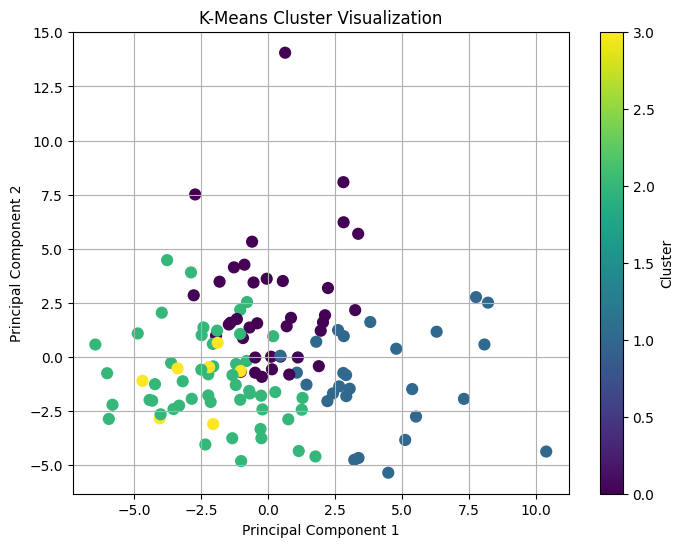

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    features_pca[:,0],
    features_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=60
)

plt.title("K-Means Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/Earthquake_project/kmeans_pca.png", dpi=300)

plt.show()

0    37
1    27
2    50
3     7
Name: count, dtype: int64


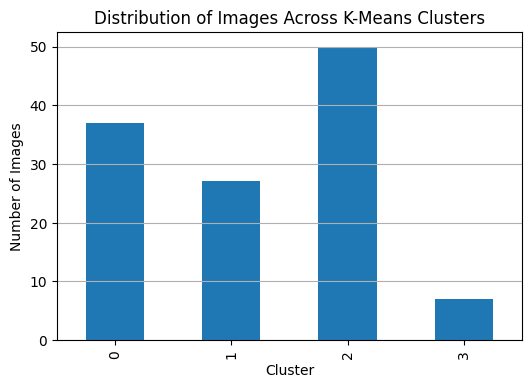

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cluster_counts = pd.Series(clusters).value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(6,4))
cluster_counts.plot(kind='bar')

plt.title("Distribution of Images Across K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Images")
plt.grid(axis='y')

plt.savefig("/content/drive/MyDrive/Earthquake_project/cluster_distribution.png", dpi=300)

plt.show()

In [ ]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [ ]:
!git remote add origin https://github.com/Aditi-Creates